This document is meant to test 1D FNO models trained on one grid size on other grid sizes to see to what extent they are discretization invariant.

In [1]:
import matplotlib.pyplot as plt
import os
from FNO1D_def import *
from utilities3 import MatReader
import glob
import re

In [2]:
#config

modes = 4
width = 64
model_path = "/scratch/mnhagen/models/burgers/with_spatial/FNO1D_burgers_1024_modes4.pt"

In [3]:
#Helper functions

def extract_N(path):
    match = re.search(r'_(\d+)\.h5$', os.path.basename(path))
    return int(match.group(1)) if match else float('inf')



def evaluate_dataset(model, dataset_path, batch_size = 20):
    """
    Function for evaluating a model on a given dataset, testing on every entry. 
    """
    dataloader = MatReader(dataset_path)

    x_test = dataloader.read_field("a").permute(2,1,0)
    y_test = dataloader.read_field("u").permute(1,0)

    n_samples, n_points, dim = x_test.shape
    
    test_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(x_test, y_test),
        batch_size = batch_size, shuffle = False
    )

    myloss = LpLoss(size_average = True)

    per_sample_losses = []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.cuda(), y.cuda()
            out = model(x)

            B = x.size(0)

            # compute loss for each item independently
            for i in range(B):
                li = myloss(
                    out[i:i+1].view(1, -1),
                    y[i:i+1].view(1, -1)
                ).item()
                per_sample_losses.append(li)

    per_sample_losses = np.array(per_sample_losses)
    mean_l2 = per_sample_losses.mean()
    std_l2 = per_sample_losses.std()
    
    return mean_l2, std_l2, n_points
    

    

In [4]:
model = FNO1D(modes, width).cuda()
model.load_state_dict(torch.load(model_path))
model.eval()

print(f"Loaded model from {model_path}")

dataset_dir = "/scratch/mnhagen/datasets/burgers/with_spatial"
pattern = os.path.join(dataset_dir, "burgers_1D_*.h5")
dataset_paths = sorted(glob.glob(pattern), key=extract_N)


results = []
for path in dataset_paths:
    mean_l2, std_l2, n_points = evaluate_dataset(model, path)

    print(f"N = {n_points} | L2 mean loss = {mean_l2:.6f} | L2 std = {std_l2}")
    results.append((n_points, mean_l2, std_l2))

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/mnhagen/models/burgers/with_spatial/FNO1D_burgers_1024_modes4.pt'

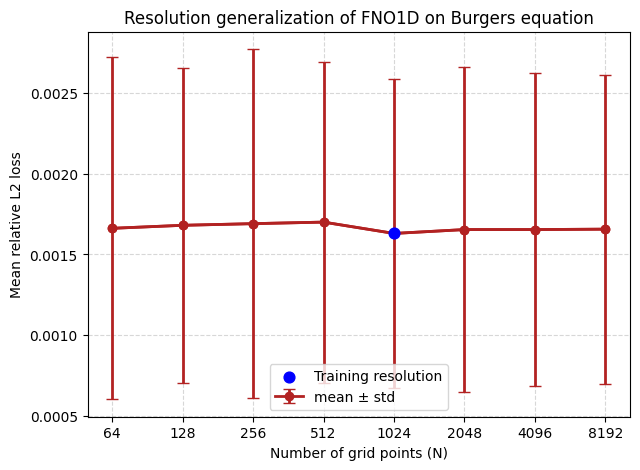

In [10]:
#plot 

plot_errors = True

resolutions, means, stds = zip(*results)

train_N = int(os.path.basename(model_path).split('_')[2])   #could break if naming convention is changed

plt.figure(figsize=(7,5))
plt.plot(resolutions, means, 'o-', color = "firebrick", lw=2)
if plot_errors:
    plt.errorbar(resolutions, means, yerr = stds, fmt = "o-", lw = 2, capsize = 4, color = "firebrick", label = "mean ± std")

if train_N in resolutions:
    i = resolutions.index(train_N)
    plt.scatter(resolutions[i], means[i], color='blue', s=60, zorder=5,
                label='Training resolution')
    
plt.xscale('log', base=2)
plt.xticks(resolutions, [str(r) for r in resolutions])
#plt.yscale('log')
plt.xlabel("Number of grid points (N)")
plt.ylabel("Mean relative L2 loss")
plt.title("Resolution generalization of FNO1D on Burgers equation")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()


#TO DO:
#modify evaluate_model to also output standard deviation
#modify this cell to also plot error bars using this standard deviation
#make the 1024 and 2048 datasets so they can be added as well   